# BeRL Grid-Search Analysis

Compare knobs across many training runs (Phase -1 stability sweep and beyond) pulled from **Weights & Biases**.

**What this notebook answers**
- Is `power` reward better than `log_prob`? Is higher `k` better than lower `k`? Does `kl`, `lr`, `fp`, `ll_min`, actor-vs-frozen RM matter?
- Grouped bar plots (mean ± std) by the knob under investigation, **conditioned on model family**.
- Stability / **collapse** analysis (brevity, length-inflation, format-hacking).
- **Which knob has the largest effect** (variance decomposition / eta squared).
- **Winning combinations** (top healthy runs, kl x reward heatmaps).
- **Consistency across model families** (do knob effects agree across Qwen2.5 / Qwen3 / Gemma?).

**Data sources**
- WandB project `jkhouja-oxford/TOM_EXP` (metrics + full run config = source of knobs).
- `project_planning/BeRL_experiments_tracker.md` (RQ tags, status, human knob labels) — joined by run name.

**Selection** — you can analyze: (a) *all* runs matching a name regex (default `Pm1swp` = the Phase -1 sweep),
(b) an explicit list of run names, or (c) a list of tracker `Exp #` row ids (e.g. `PS075`).

> Metrics are cached to `notebooks/_cache/grid_metrics.parquet`. Re-run the fetch cell with `FORCE_REFRESH=True` to re-pull.


## 0. Setup

In [1]:
import os, re, json, warnings, math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

# --- configuration ---------------------------------------------------------
WANDB_ENTITY  = "jkhouja-oxford"
WANDB_PROJECT = "TOM_EXP"
WANDB_PATH    = f"{WANDB_ENTITY}/{WANDB_PROJECT}"

REPO_ROOT   = Path("..").resolve()
TRACKER     = REPO_ROOT / "project_planning" / "BeRL_experiments_tracker.md"
CACHE_DIR   = Path("_cache"); CACHE_DIR.mkdir(exist_ok=True)
CACHE_FILE  = CACHE_DIR / "grid_metrics.parquet"

# Which runs to pull. Regex is matched against the WandB run display name.
# 'Pm1swp' = the Phase -1 stability sweep. Use '' to pull the whole project.
NAME_REGEX    = "Pm1swp"
FORCE_REFRESH = False          # set True to re-pull from WandB (ignores cache)

# collapse thresholds (response_length/mean, tokens)
BREVITY_MAX   = 70.0           # final length below this  -> brevity collapse
INFLATION_MAX = 140.0          # peak  length above this  -> length-inflation collapse
FORMAT_HACK   = 0.05           # max format_error_ratio above this -> format hacking
print("Repo:", REPO_ROOT)
print("Tracker exists:", TRACKER.exists(), "| cache exists:", CACHE_FILE.exists())


Repo: /mnt/home/judekhouja/repo/BeRL
Tracker exists: True | cache exists: False


## 1. Parse the tracker

Reads the markdown coordination table into a DataFrame so we can join RQ tags / status / human knob
labels onto the WandB metrics, and so we can select runs by tracker `Exp #` (e.g. `PS075`).

In [2]:
def load_tracker(path=TRACKER):
    lines = Path(path).read_text().splitlines()
    hdr_i = next(i for i, l in enumerate(lines) if l.strip().startswith("| Exp #"))
    cols = [c.strip() for c in lines[hdr_i].strip().strip("|").split("|")]
    rows = []
    for l in lines[hdr_i + 2:]:                       # +2 skips the |---| separator
        if not l.strip().startswith("|"):
            continue
        cells = [c.strip() for c in l.strip().strip("|").split("|")]
        if len(cells) != len(cols):
            continue
        rows.append(cells)
    df = pd.DataFrame(rows, columns=cols)
    return df

def parse_notes(note):
    """Extract knob key=values from the tracker 'Notes' column (backup for config)."""
    out = {}
    for m in re.finditer(r"(\w+)=([^\s]+)", str(note)):
        out[m.group(1)] = m.group(2)
    return out

tracker = load_tracker()
print("tracker rows:", len(tracker))
print("statuses:", tracker["Status"].value_counts().to_dict())
tracker[["Exp #", "Run name", "Status", "Notes"]].head(8)


tracker rows: 168
statuses: {'Completed': 83, 'Backlog': 81, 'Training': 4}


,Exp #,Run name,Status,Notes
0,PS001,Phase-stability-Pm1swp_rmf_kl0.01_lr5e-7_fp0_e...,Completed,rm=frozen kl=0.01 lr=5e-7 fp=0 ec=0.0 reward=l...
1,PS002,Phase-stability-Pm1swp_rmf_kl0.01_lr5e-7_fp0_e...,Completed,rm=frozen kl=0.01 lr=5e-7 fp=0 ec=0.001 reward...
2,PS003,Phase-stability-Pm1swp_rmf_kl0.01_lr5e-7_fp5_e...,Completed,rm=frozen kl=0.01 lr=5e-7 fp=5 ec=0.0 reward=l...
3,PS004,Phase-stability-Pm1swp_rmf_kl0.01_lr5e-7_fp5_e...,Completed,rm=frozen kl=0.01 lr=5e-7 fp=5 ec=0.001 reward...
4,PS005,Phase-stability-Pm1swp_rmf_kl0.01_lr1e-6_fp0_e...,Completed,rm=frozen kl=0.01 lr=1e-6 fp=0 ec=0.0 reward=l...
5,PS006,Phase-stability-Pm1swp_rmf_kl0.01_lr1e-6_fp0_e...,Completed,rm=frozen kl=0.01 lr=1e-6 fp=0 ec=0.001 reward...
6,PS007,Phase-stability-Pm1swp_rmf_kl0.01_lr1e-6_fp5_e...,Completed,rm=frozen kl=0.01 lr=1e-6 fp=5 ec=0.0 reward=l...
7,PS008,Phase-stability-Pm1swp_rmf_kl0.01_lr1e-6_fp5_e...,Completed,rm=frozen kl=0.01 lr=1e-6 fp=5 ec=0.001 reward...


## 2. Fetch metrics from WandB

For every matching run we pull:
- **config** -> knobs (reward type, k, ll_min, RM mode, kl, lr, format penalty, entropy, baseline, model family/size),
- **baseline** (step-0 validation) and **final** validation for all `val/test_score/*_sub300` benchmarks,
- **trajectory** summaries for health: response length (baseline / final / peak), reward, format-error, kl.

Results are cached to parquet. One row per run (wide); per-benchmark deltas are exploded later.

In [3]:
import wandb

# ---- config helpers -------------------------------------------------------
def cfg_get(cfg, dotted, default=None):
    cur = cfg
    for part in dotted.split("."):
        if isinstance(cur, dict) and part in cur:
            cur = cur[part]
        else:
            return default
    return cur

def model_family_size(path):
    p = str(path or "")
    fam = "unknown"; size = "unknown"
    low = p.lower()
    if "qwen3" in low: fam = "Qwen3"
    elif "qwen2.5" in low or "qwen2_5" in low: fam = "Qwen2.5"
    elif "gemma-2" in low or "gemma2" in low: fam = "Gemma-2"
    elif "llama" in low: fam = "Llama"
    m = re.search(r"(\d+\.?\d*)\s*[bB]\b", p)
    if m: size = m.group(1) + "B"
    return fam, size

VAL_PREFIX = "val/test_score/"
def is_val_key(k): return k.startswith(VAL_PREFIX)
def bench_name(k):  return k[len(VAL_PREFIX):].replace("_sub300", "")

def first_last_valid(series):
    s = series.dropna()
    if len(s) == 0: return (np.nan, np.nan)
    return (s.iloc[0], s.iloc[-1])

def find_col(cols, *subs):
    for c in cols:
        cl = c.lower()
        if all(s in cl for s in subs):
            return c
    return None

def fetch_one(run):
    cfg = run.config
    rm  = cfg.get("reward_model", {}) if isinstance(cfg.get("reward_model", {}), dict) else {}
    fam, size = model_family_size(cfg_get(cfg, "actor_rollout_ref.model.path")
                                  or cfg_get(cfg, "reward_model.model.path"))
    rec = dict(
        run_name   = run.name,
        run_id     = run.id,
        state      = run.state,
        url        = run.url,
        reward_type= rm.get("reward_type"),
        power_k    = rm.get("power_k"),
        ll_min     = rm.get("power_ll_min"),
        rm_mode    = "actor" if rm.get("use_actor_as_rm") else "frozen",
        subtract_baseline = bool(rm.get("subtract_baseline")),
        format_penalty    = rm.get("format_penalty"),
        kl = cfg_get(cfg, "actor_rollout_ref.actor.kl_loss_coef",
                     cfg_get(cfg, "algorithm.kl_ctrl.kl_coef")),
        lr = cfg_get(cfg, "actor_rollout_ref.actor.optim.lr"),
        entropy_coeff = cfg_get(cfg, "actor_rollout_ref.actor.entropy_coeff"),
        rollout_n     = cfg_get(cfg, "actor_rollout_ref.rollout.n"),
        model_family  = fam,
        model_size    = size,
    )
    # cot prompt variant / data config from run name (best effort)
    mcot = re.search(r"(cot[_a-z]*|COT[_A-Z]*)", run.name)
    rec["cot_var"] = mcot.group(1) if mcot else None
    mdc = re.search(r"(dcfg_[a-z0-9_]+)", run.name)
    rec["data_cfg"] = mdc.group(1) if mdc else None

    # ---- history: one pull, all columns ----
    try:
        h = run.history(samples=4000)
    except Exception as e:
        h = pd.DataFrame()
    baseline, final = {}, {}
    if len(h):
        val_cols = [c for c in h.columns if is_val_key(c)]
        for c in val_cols:
            b, f = first_last_valid(h[c])
            baseline[bench_name(c)] = b
            final[bench_name(c)] = f
        len_col = find_col(h.columns, "response_length", "mean")
        rew_col = find_col(h.columns, "reward", "mean") or find_col(h.columns, "critic", "rewards", "mean")
        fmt_col = find_col(h.columns, "format_error") or find_col(h.columns, "format", "ratio")
        kl_col  = find_col(h.columns, "actor", "kl_loss") or find_col(h.columns, "kl", "mean")
        if len_col:
            lb, lf = first_last_valid(h[len_col])
            rec["len_baseline"] = lb; rec["len_final"] = lf
            rec["len_peak"] = np.nanmax(h[len_col].values) if h[len_col].notna().any() else np.nan
        if rew_col:
            rb, rf = first_last_valid(h[rew_col])
            rec["reward_baseline"] = rb; rec["reward_final"] = rf
        if fmt_col:
            rec["format_max"] = np.nanmax(h[fmt_col].values) if h[fmt_col].notna().any() else np.nan
        if kl_col:
            rec["kl_final"] = first_last_valid(h[kl_col])[1]
        rec["n_steps"] = int(h["_step"].max()) if "_step" in h else np.nan

    # fall back to summary for finals if history missed them
    for k, v in dict(run.summary).items():
        if is_val_key(k) and (bench_name(k) not in final or pd.isna(final.get(bench_name(k)))):
            final[bench_name(k)] = v
    rec["_baseline"] = baseline
    rec["_final"] = final
    return rec

def fetch_runs(name_regex=NAME_REGEX, force=FORCE_REFRESH):
    if CACHE_FILE.exists() and not force:
        print("Loading cached metrics from", CACHE_FILE)
        return pd.read_parquet(CACHE_FILE)
    api = wandb.Api()
    filt = {"display_name": {"$regex": name_regex}} if name_regex else None
    runs = api.runs(WANDB_PATH, filters=filt)
    print(f"Fetching {len(runs)} runs matching /{name_regex}/ ...")
    recs = []
    for i, r in enumerate(runs):
        try:
            recs.append(fetch_one(r))
        except Exception as e:
            print("  ! skip", r.name, "->", e)
        if (i + 1) % 10 == 0:
            print(f"  {i+1}/{len(runs)}")
    df = pd.DataFrame(recs)
    # serialize nested dicts to json for parquet
    df["_baseline"] = df["_baseline"].apply(json.dumps)
    df["_final"] = df["_final"].apply(json.dumps)
    df.to_parquet(CACHE_FILE)
    print("Cached ->", CACHE_FILE)
    return df

raw = fetch_runs()
print("runs:", len(raw))
raw[["run_name","reward_type","power_k","kl","lr","rm_mode","format_penalty","model_family"]].head()


wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.


Fetching 97 runs matching /Pm1swp/ ...


  10/97


  20/97


  30/97


...

  70/97


  80/97


  90/97


Cached -> _cache/grid_metrics.parquet
runs: 97


,run_name,reward_type,power_k,kl,lr,rm_mode,format_penalty,model_family
0,Phase-stability-Pm1swp_rmf_kl0.01_lr5e-7_fp0_e...,log_prob,2,0.01,5.000000e-07,frozen,0,Qwen2.5
1,Phase-stability-Pm1swp_rmf_kl0.01_lr5e-7_fp0_e...,log_prob,2,0.01,5.000000e-07,frozen,0,Qwen2.5
2,Phase-stability-Pm1swp_rmf_kl0.01_lr5e-7_fp5_e...,log_prob,2,0.01,5.000000e-07,frozen,5,Qwen2.5
3,Phase-stability-Pm1swp_rmf_kl0.01_lr5e-7_fp5_e...,log_prob,2,0.01,5.000000e-07,frozen,5,Qwen2.5
4,Phase-stability-Pm1swp_rmf_kl0.01_lr1e-6_fp0_e...,log_prob,2,0.01,1.000000e-06,frozen,0,Qwen2.5


## 3. Build the tidy analysis frame

- `runs_df` — one row per run with knob columns + health metrics + **aggregate delta** (mean over benchmarks
  of `final - baseline`, in percentage points) and **aggregate final**.
- `long_df` — one row per (run, benchmark) for per-benchmark analysis.
- Collapse flags computed from the thresholds in cell 0.

In [4]:
def unpack(df):
    df = df.copy()
    base = df["_baseline"].apply(lambda s: json.loads(s) if isinstance(s, str) else (s or {}))
    fin  = df["_final"].apply(lambda s: json.loads(s) if isinstance(s, str) else (s or {}))
    df["_baseline"] = base; df["_final"] = fin
    # aggregate delta / final over the benchmarks present in each run
    def agg(row):
        b, f = row["_baseline"], row["_final"]
        keys = [k for k in f if k in b and pd.notna(b[k]) and pd.notna(f[k])]
        if not keys:
            return pd.Series(dict(agg_delta=np.nan, agg_final=np.nan, n_bench=0))
        d = np.mean([(f[k] - b[k]) for k in keys]) * 100.0
        ff = np.mean([f[k] for k in keys]) * 100.0
        return pd.Series(dict(agg_delta=d, agg_final=ff, n_bench=len(keys)))
    df = pd.concat([df, df.apply(agg, axis=1)], axis=1)
    return df

def add_health(df):
    df = df.copy()
    df["brevity_collapse"]   = df.get("len_final", np.nan) < BREVITY_MAX
    df["inflation_collapse"] = df.get("len_peak",  np.nan) > INFLATION_MAX
    df["format_hack"]        = df.get("format_max", np.nan) > FORMAT_HACK
    df["collapsed"] = df[["brevity_collapse","inflation_collapse","format_hack"]].any(axis=1)
    df["health"] = np.where(df["collapsed"], "COLLAPSE", "healthy")
    return df

# knob label helpers (readable categorical strings)
def mk_labels(df):
    df = df.copy()
    df["kl"]   = pd.to_numeric(df["kl"], errors="coerce")
    df["lr"]   = pd.to_numeric(df["lr"], errors="coerce")
    df["power_k"] = pd.to_numeric(df["power_k"], errors="coerce")
    df["ll_min"]  = pd.to_numeric(df["ll_min"], errors="coerce")
    df["format_penalty"] = pd.to_numeric(df["format_penalty"], errors="coerce")
    df["entropy_coeff"]  = pd.to_numeric(df["entropy_coeff"], errors="coerce")
    df["k_lbl"]  = df["power_k"].apply(lambda x: f"k={x:g}" if pd.notna(x) else "k=NA")
    df["kl_lbl"] = df["kl"].apply(lambda x: f"kl={x:g}" if pd.notna(x) else "kl=NA")
    df["lr_lbl"] = df["lr"].apply(lambda x: f"lr={x:g}" if pd.notna(x) else "lr=NA")
    df["fp_lbl"] = df["format_penalty"].apply(lambda x: f"fp={x:g}" if pd.notna(x) else "fp=NA")
    df["fam_size"] = df["model_family"] + "-" + df["model_size"].astype(str)
    return df

runs_df = mk_labels(add_health(unpack(raw)))
print("runs:", len(runs_df), "| healthy:", int((~runs_df.collapsed).sum()),
      "| collapsed:", int(runs_df.collapsed.sum()))
print("families:", runs_df["fam_size"].value_counts().to_dict())
runs_df[["run_name","reward_type","k_lbl","kl_lbl","lr_lbl","fp_lbl","rm_mode",
         "len_final","len_peak","agg_delta","health"]].head(10)


runs: 97 | healthy: 56 | collapsed: 41
families: {'Qwen2.5-3B': 97}


,run_name,reward_type,k_lbl,kl_lbl,lr_lbl,fp_lbl,rm_mode,len_final,len_peak,agg_delta,health
0,Phase-stability-Pm1swp_rmf_kl0.01_lr5e-7_fp0_e...,log_prob,k=2,kl=0.01,lr=5e-07,fp=0,frozen,127.998047,170.412109,-14.871795,COLLAPSE
1,Phase-stability-Pm1swp_rmf_kl0.01_lr5e-7_fp0_e...,log_prob,k=2,kl=0.01,lr=5e-07,fp=0,frozen,138.957031,161.015625,-21.179487,COLLAPSE
2,Phase-stability-Pm1swp_rmf_kl0.01_lr5e-7_fp5_e...,log_prob,k=2,kl=0.01,lr=5e-07,fp=5,frozen,128.662109,177.964844,-13.551282,COLLAPSE
3,Phase-stability-Pm1swp_rmf_kl0.01_lr5e-7_fp5_e...,log_prob,k=2,kl=0.01,lr=5e-07,fp=5,frozen,136.984375,196.587891,-7.512821,COLLAPSE
4,Phase-stability-Pm1swp_rmf_kl0.01_lr1e-6_fp0_e...,log_prob,k=2,kl=0.01,lr=1e-06,fp=0,frozen,131.630859,219.164062,-13.500000,COLLAPSE
5,Phase-stability-Pm1swp_rmf_kl0.01_lr1e-6_fp0_e...,log_prob,k=2,kl=0.01,lr=1e-06,fp=0,frozen,149.107422,171.285156,-18.602564,COLLAPSE
6,Phase-stability-Pm1swp_rmf_kl0.01_lr1e-6_fp5_e...,log_prob,k=2,kl=0.01,lr=1e-06,fp=5,frozen,174.630859,174.630859,-25.115385,COLLAPSE
7,Phase-stability-Pm1swp_rmf_kl0.01_lr1e-6_fp5_e...,log_prob,k=2,kl=0.01,lr=1e-06,fp=5,frozen,124.265625,168.244141,-8.269231,COLLAPSE
8,Phase-stability-Pm1swp_rmf_kl0.05_lr5e-7_fp0_e...,log_prob,k=2,kl=0.05,lr=5e-07,fp=0,frozen,118.980469,131.203125,-1.269231,healthy
9,Phase-stability-Pm1swp_rmf_kl0.05_lr5e-7_fp0_e...,log_prob,k=2,kl=0.05,lr=5e-07,fp=0,frozen,124.328125,142.484375,-1.487179,COLLAPSE


In [5]:
# long-form: one row per (run, benchmark)
def to_long(df):
    recs = []
    for _, r in df.iterrows():
        b, f = r["_baseline"], r["_final"]
        for k in f:
            if k in b and pd.notna(b[k]) and pd.notna(f[k]):
                recs.append(dict(run_name=r["run_name"], benchmark=k,
                                 baseline=b[k]*100, final=f[k]*100, delta=(f[k]-b[k])*100,
                                 reward_type=r["reward_type"], power_k=r["power_k"], kl=r["kl"],
                                 lr=r["lr"], rm_mode=r["rm_mode"], format_penalty=r["format_penalty"],
                                 ll_min=r["ll_min"], model_family=r["model_family"],
                                 fam_size=r["fam_size"], health=r["health"]))
    return pd.DataFrame(recs)

long_df = to_long(runs_df)
print("long rows:", len(long_df), "| benchmarks:", long_df["benchmark"].nunique())
long_df.head()


long rows: 2496 | benchmarks: 26


,run_name,benchmark,baseline,final,delta,reward_type,power_k,kl,lr,rm_mode,format_penalty,ll_min,model_family,fam_size,health
0,Phase-stability-Pm1swp_rmf_kl0.01_lr5e-7_fp0_e...,gsm8k,66.333333,40.333333,-26.000000,log_prob,2,0.01,5.000000e-07,frozen,0,-8,Qwen2.5,Qwen2.5-3B,COLLAPSE
1,Phase-stability-Pm1swp_rmf_kl0.01_lr5e-7_fp0_e...,tombench,60.666667,46.333333,-14.333333,log_prob,2,0.01,5.000000e-07,frozen,0,-8,Qwen2.5,Qwen2.5-3B,COLLAPSE
2,Phase-stability-Pm1swp_rmf_kl0.01_lr5e-7_fp0_e...,simpletom_behavior,56.000000,53.666667,-2.333333,log_prob,2,0.01,5.000000e-07,frozen,0,-8,Qwen2.5,Qwen2.5-3B,COLLAPSE
3,Phase-stability-Pm1swp_rmf_kl0.01_lr5e-7_fp0_e...,dyntom_type_a,50.666667,22.000000,-28.666667,log_prob,2,0.01,5.000000e-07,frozen,0,-8,Qwen2.5,Qwen2.5-3B,COLLAPSE
4,Phase-stability-Pm1swp_rmf_kl0.01_lr5e-7_fp0_e...,opentom_multihop_so,48.666667,24.000000,-24.666667,log_prob,2,0.01,5.000000e-07,frozen,0,-8,Qwen2.5,Qwen2.5-3B,COLLAPSE


## 4. Compare a knob (grouped bar, mean ± std)

`compare_knob(knob, metric, by_family)` groups runs by the knob (optionally x model family) and plots
mean ± std. Use `metric='agg_delta'` (learning), `'agg_final'` (final score), `'len_final'` / `'len_peak'`
(stability), `'reward_final'`, `'format_max'`.

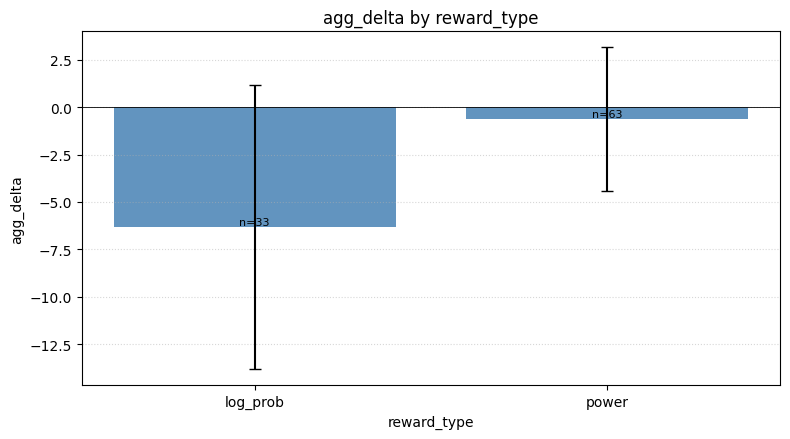

In [6]:
KNOB_COLS = {
    "reward_type": "reward_type", "k": "k_lbl", "kl": "kl_lbl", "lr": "lr_lbl",
    "fp": "fp_lbl", "rm_mode": "rm_mode", "ll_min": "ll_min",
    "entropy_coeff": "entropy_coeff", "subtract_baseline": "subtract_baseline",
}

def _order(vals):
    try:    return sorted(vals, key=lambda v: (float(re.sub(r"[^0-9.eE+-]", "", str(v))), str(v)))
    except Exception: return sorted(map(str, vals))

def compare_knob(knob, metric="agg_delta", by_family=False, healthy_only=False,
                 df=None, ax=None, title=None):
    df = runs_df if df is None else df
    col = KNOB_COLS.get(knob, knob)
    d = df[df[col].notna() & df[metric].notna()].copy()
    if healthy_only: d = d[~d["collapsed"]]
    if d.empty:
        print("no data for", knob, metric); return None
    ax = ax or plt.subplots(figsize=(8, 4.5))[1]
    if by_family and d["fam_size"].nunique() > 1:
        fams = _order(d["fam_size"].unique()); knobs = _order(d[col].unique())
        x = np.arange(len(knobs)); w = 0.8 / max(len(fams), 1)
        for i, fam in enumerate(fams):
            sub = d[d["fam_size"] == fam]
            g = sub.groupby(col)[metric]
            means = [g.mean().get(k, np.nan) for k in knobs]
            stds  = [g.std().get(k,  np.nan) for k in knobs]
            ax.bar(x + i*w, means, w, yerr=stds, capsize=3, label=str(fam))
        ax.set_xticks(x + w*(len(fams)-1)/2); ax.set_xticklabels([str(k) for k in knobs])
        ax.legend(fontsize=8, title="family")
    else:
        g = d.groupby(col)[metric]
        knobs = _order(g.mean().index)
        means = [g.mean()[k] for k in knobs]; stds = [g.std()[k] for k in knobs]
        ns = [int(g.count()[k]) for k in knobs]
        bars = ax.bar([str(k) for k in knobs], means, yerr=stds, capsize=4,
                      color="steelblue", alpha=0.85)
        for b, n in zip(bars, ns):
            ax.text(b.get_x()+b.get_width()/2, b.get_height(), f"n={n}",
                    ha="center", va="bottom", fontsize=8)
    ax.axhline(0, color="k", lw=0.6)
    ax.set_ylabel(metric); ax.set_xlabel(knob)
    ax.set_title(title or f"{metric} by {knob}" + (" (x family)" if by_family else ""))
    ax.grid(axis="y", ls=":", alpha=0.5)
    return ax

compare_knob("reward_type", "agg_delta"); plt.tight_layout(); plt.show()


### 4a. Is `power` better than `log_prob`?

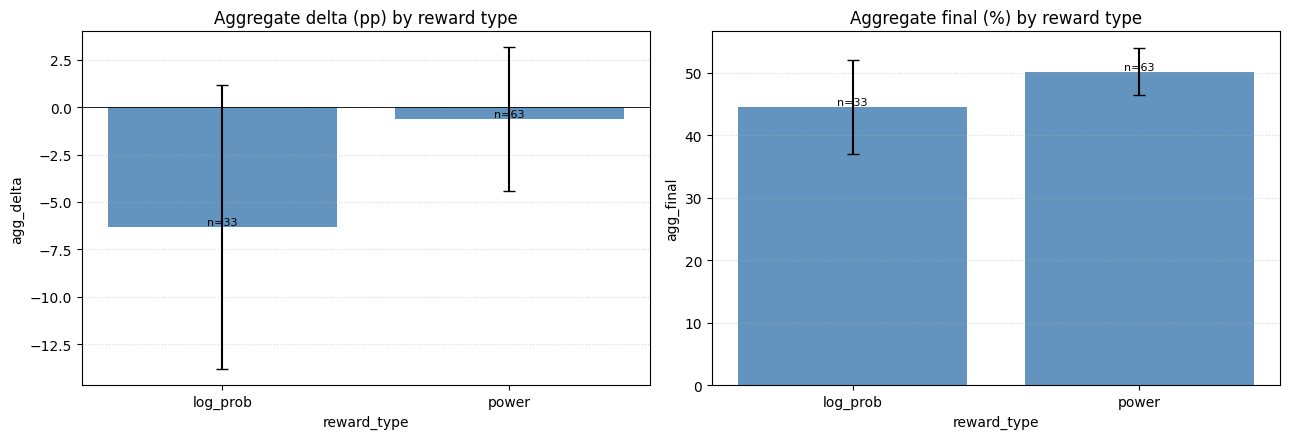

Means by reward_type:
            agg_delta             agg_final             len_final              len_peak             
                 mean   std count      mean   std count      mean    std count     mean    std count
reward_type                                                                                         
log_prob        -6.32  7.51    33     44.46  7.50    33    114.87  26.26    33   144.85  24.70    33
power           -0.62  3.78    63     50.16  3.77    63    112.87  26.09    63   137.34  17.34    63


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
compare_knob("reward_type", "agg_delta", ax=axes[0], title="Aggregate delta (pp) by reward type")
compare_knob("reward_type", "agg_final", ax=axes[1], title="Aggregate final (%) by reward type")
plt.tight_layout(); plt.show()

print("Means by reward_type:")
print(runs_df.groupby("reward_type")[["agg_delta","agg_final","len_final","len_peak"]]
      .agg(["mean","std","count"]).round(2))


### 4b. Is higher `k` better than lower `k`? (power runs only)

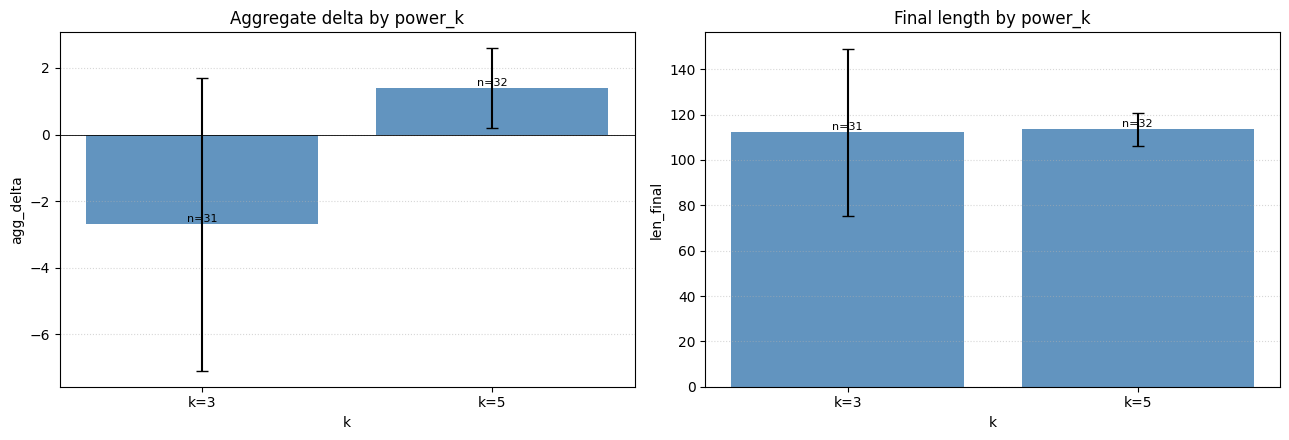

        agg_delta             len_final              len_peak            
             mean   std count      mean    std count     mean   std count
power_k                                                                  
3           -2.70  4.38    31    112.13  36.73    31   142.51  22.1    31
5            1.39  1.19    32    113.58   7.36    32   132.33   8.7    32


In [8]:
pw = runs_df[runs_df["reward_type"] == "power"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
compare_knob("k", "agg_delta", df=pw, ax=axes[0], title="Aggregate delta by power_k")
compare_knob("k", "len_final", df=pw, ax=axes[1], title="Final length by power_k")
plt.tight_layout(); plt.show()
print(pw.groupby("power_k")[["agg_delta","len_final","len_peak"]].agg(["mean","std","count"]).round(2))


### 4c. KL, LR, format-penalty, RM mode, ll_min

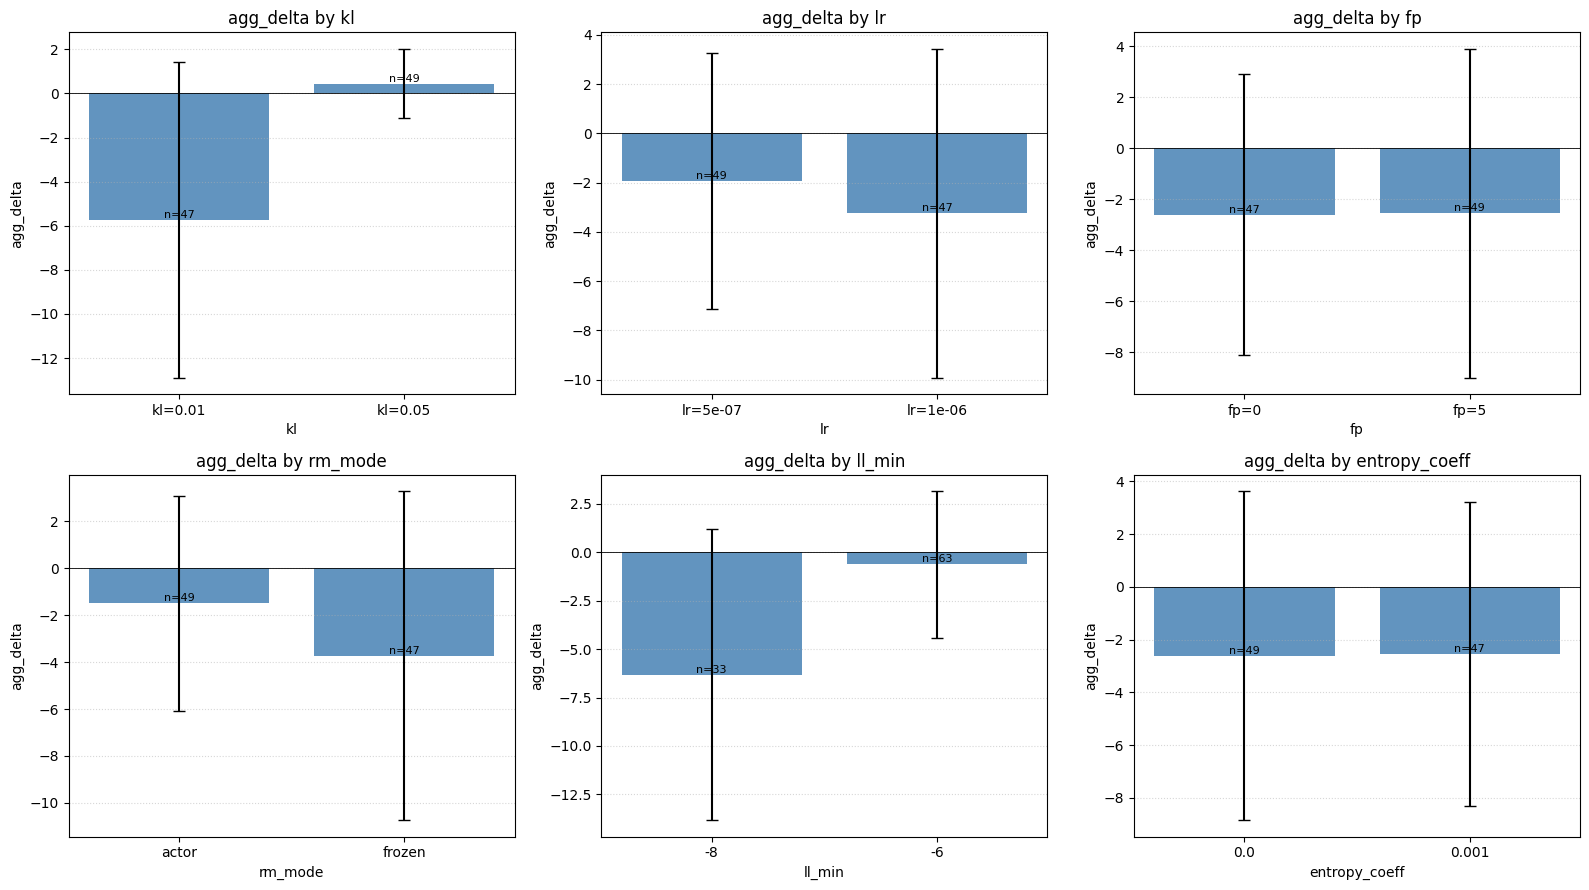

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, knob in zip(axes.flat, ["kl", "lr", "fp", "rm_mode", "ll_min", "entropy_coeff"]):
    compare_knob(knob, "agg_delta", ax=ax)
plt.tight_layout(); plt.show()


### 4d. Conditioned on model family
Same comparison split by model family — reveals whether a knob's effect is family-specific.

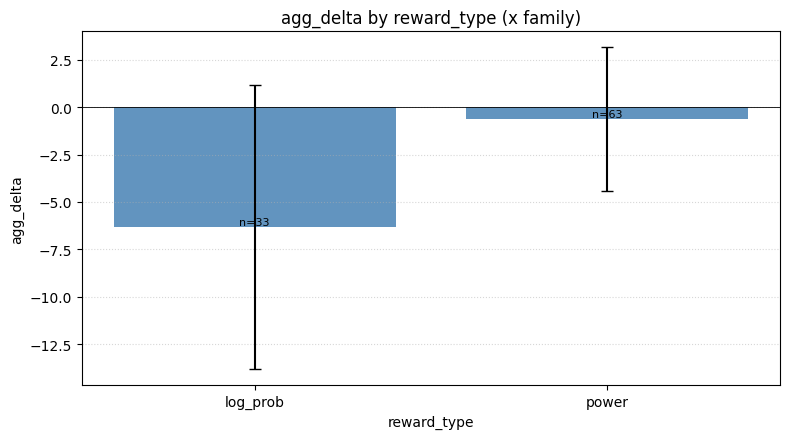

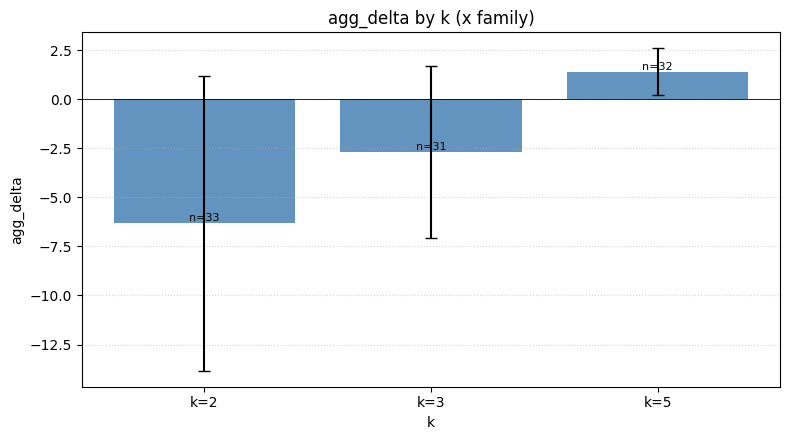

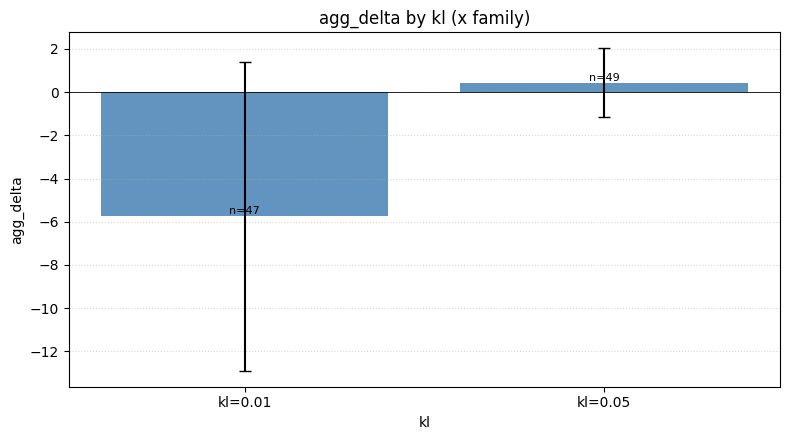

In [10]:
for knob in ["reward_type", "k", "kl"]:
    compare_knob(knob, "agg_delta", by_family=True); plt.tight_layout(); plt.show()


## 5. Stability & collapse analysis

Length is the main stability signal. We flag **brevity collapse** (final length < `BREVITY_MAX`),
**length-inflation collapse** (peak length > `INFLATION_MAX`) and **format hacking**
(max format-error > `FORMAT_HACK`). Thresholds are set in cell 0.

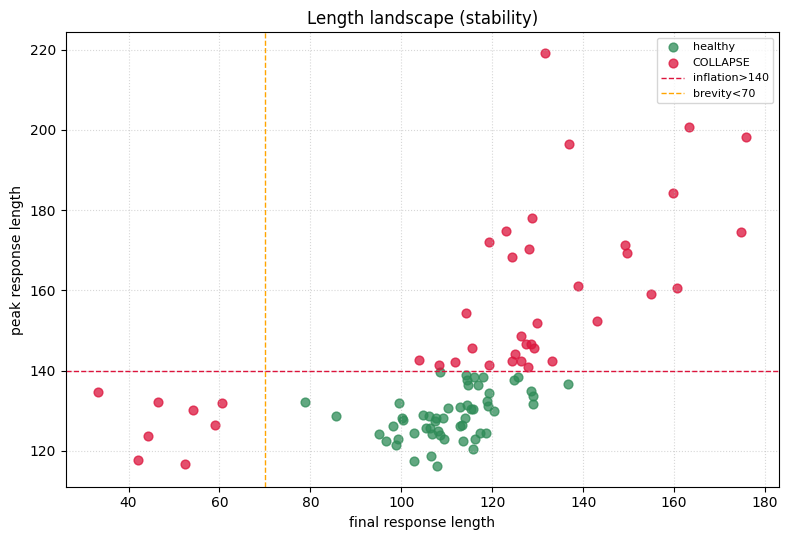

Collapse counts: {'healthy': 56, 'collapsed': 41}
                                                                                                                                                   run_name reward_type k_lbl  kl_lbl fp_lbl rm_mode  len_final   len_peak  format_max  brevity_collapse  inflation_collapse  format_hack
  Phase-stability-Pm1swp_rmf_kl0.01_lr5e-7_fp0_ec0.0_lp-dcfg_smoke_mix-Qwen2.5-3B-Instruct-frozenRM-nobaseline-log_prob-k2.0-llmin-8.0-lr5e-7-kl0.01-n16-r1    log_prob   k=2 kl=0.01   fp=0  frozen 127.998047 170.412109         0.0             False                True        False
Phase-stability-Pm1swp_rmf_kl0.01_lr5e-7_fp0_ec0.001_lp-dcfg_smoke_mix-Qwen2.5-3B-Instruct-frozenRM-nobaseline-log_prob-k2.0-llmin-8.0-lr5e-7-kl0.01-n16-r1    log_prob   k=2 kl=0.01   fp=0  frozen 138.957031 161.015625         0.0             False                True        False
  Phase-stability-Pm1swp_rmf_kl0.01_lr5e-7_fp5_ec0.0_lp-dcfg_smoke_mix-Qwen2.5-3B-Instruct-frozenRM-noba

In [11]:
# 5a. length landscape: peak vs final, colored by health
fig, ax = plt.subplots(figsize=(8, 5.5))
for hl, c in [("healthy", "seagreen"), ("COLLAPSE", "crimson")]:
    s = runs_df[runs_df["health"] == hl]
    ax.scatter(s["len_final"], s["len_peak"], c=c, label=hl, alpha=0.75, s=40)
ax.axhline(INFLATION_MAX, color="crimson", ls="--", lw=1, label=f"inflation>{INFLATION_MAX:g}")
ax.axvline(BREVITY_MAX,  color="orange",  ls="--", lw=1, label=f"brevity<{BREVITY_MAX:g}")
ax.set_xlabel("final response length"); ax.set_ylabel("peak response length")
ax.set_title("Length landscape (stability)"); ax.legend(fontsize=8); ax.grid(ls=":", alpha=0.5)
plt.tight_layout(); plt.show()

print("Collapse counts:",
      dict(healthy=int((~runs_df.collapsed).sum()), collapsed=int(runs_df.collapsed.sum())))
print(runs_df[runs_df.collapsed][["run_name","reward_type","k_lbl","kl_lbl","fp_lbl","rm_mode",
      "len_final","len_peak","format_max","brevity_collapse","inflation_collapse","format_hack"]]
      .to_string(index=False))


In [12]:
# 5b. collapse RATE by knob -> what causes collapse?
def collapse_rate(knob):
    col = KNOB_COLS.get(knob, knob)
    g = runs_df.groupby(col)["collapsed"].agg(["mean","count"])
    g.columns = ["collapse_rate", "n"]
    return g.round(3)

for knob in ["kl", "reward_type", "k", "fp", "rm_mode", "lr"]:
    print(f"\n== collapse rate by {knob} ==")
    print(collapse_rate(knob))



== collapse rate by kl ==
         collapse_rate   n
kl_lbl                    
kl=0.01          0.646  48
kl=0.05          0.204  49

== collapse rate by reward_type ==
             collapse_rate   n
reward_type                   
log_prob             0.606  33
power                0.328  64

== collapse rate by k ==
       collapse_rate   n
k_lbl                   
k=2            0.606  33
k=3            0.469  32
k=5            0.188  32

== collapse rate by fp ==
        collapse_rate   n
fp_lbl                   
fp=0            0.438  48
fp=5            0.408  49

== collapse rate by rm_mode ==
         collapse_rate   n
rm_mode                   
actor            0.327  49
frozen           0.521  48

== collapse rate by lr ==
          collapse_rate   n
lr_lbl                     
lr=1e-06          0.625  48
lr=5e-07          0.224  49


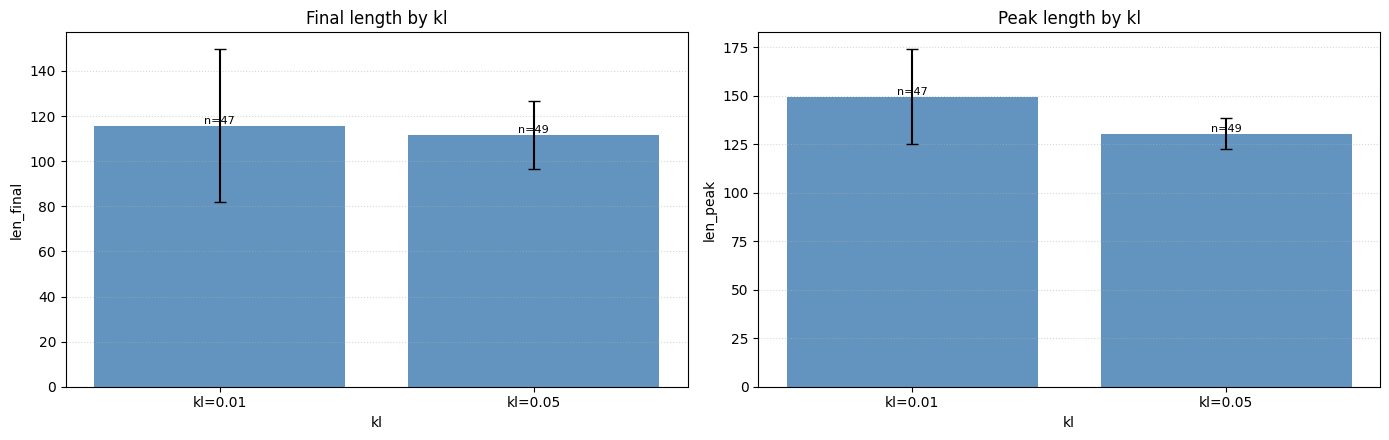

In [13]:
# 5c. length by knob (stability view): grouped bars of final + peak length
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
compare_knob("kl", "len_final", ax=axes[0], title="Final length by kl")
compare_knob("kl", "len_peak",  ax=axes[1], title="Peak length by kl")
plt.tight_layout(); plt.show()


## 6. Which knob has the largest effect?

**eta squared** = between-group variance / total variance for a metric, per knob. Higher = the knob
explains more of the spread in outcomes. Computed for learning (`agg_delta`) and stability (`len_final`).

,eta2_agg_delta,eta2_len_final,eta2_agg_final
k,0.285,0.002,0.286
kl,0.270,0.007,0.270
reward_type,0.207,0.001,0.208
ll_min,0.207,0.001,0.208
rm_mode,0.036,0.270,0.037
lr,0.012,0.000,0.012
fp,0.000,0.002,0.000
entropy_coeff,0.000,0.000,0.000
subtract_baseline,NaN,NaN,NaN


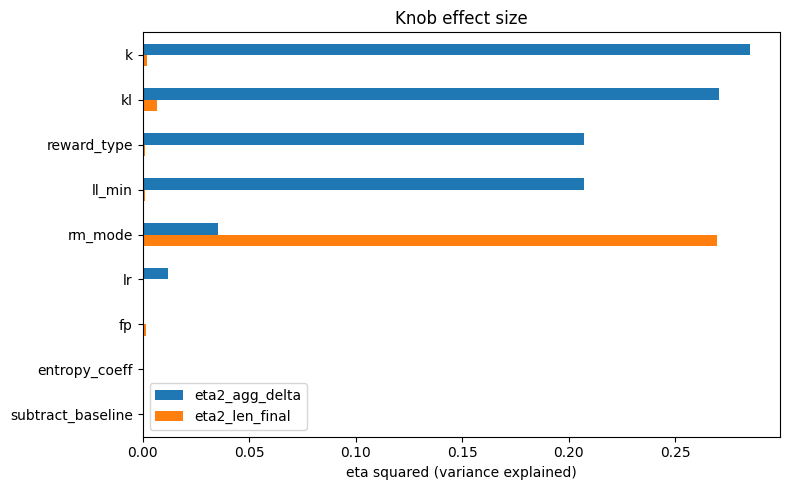

In [14]:
def eta_squared(metric, knob, df=None):
    df = runs_df if df is None else df
    col = KNOB_COLS.get(knob, knob)
    d = df[df[col].notna() & df[metric].notna()]
    if d[col].nunique() < 2 or len(d) < 3:
        return np.nan
    grand = d[metric].mean()
    ss_tot = ((d[metric] - grand) ** 2).sum()
    ss_between = sum(len(g) * (g[metric].mean() - grand) ** 2 for _, g in d.groupby(col))
    return ss_between / ss_tot if ss_tot > 0 else np.nan

KNOBS = ["reward_type", "k", "kl", "lr", "fp", "rm_mode", "ll_min", "entropy_coeff", "subtract_baseline"]
eff = pd.DataFrame({
    "eta2_agg_delta": {k: eta_squared("agg_delta", k) for k in KNOBS},
    "eta2_len_final": {k: eta_squared("len_final", k) for k in KNOBS},
    "eta2_agg_final": {k: eta_squared("agg_final", k) for k in KNOBS},
}).sort_values("eta2_agg_delta", ascending=False)
display(eff.round(3))

ax = eff[["eta2_agg_delta","eta2_len_final"]].plot.barh(figsize=(8,5))
ax.set_xlabel("eta squared (variance explained)"); ax.set_title("Knob effect size")
ax.invert_yaxis(); plt.tight_layout(); plt.show()


## 7. Winning combinations

Top healthy runs by aggregate delta, and knob-pair heatmaps of mean learning and collapse rate.

In [15]:
# 7a. top healthy runs
top = (runs_df[~runs_df["collapsed"]]
       .sort_values("agg_delta", ascending=False)
       [["run_name","reward_type","k_lbl","kl_lbl","lr_lbl","fp_lbl","rm_mode",
         "agg_delta","agg_final","len_final","len_peak"]]
       .head(15).round(2))
print("TOP 15 healthy runs by aggregate delta:")
display(top)


TOP 15 healthy runs by aggregate delta:


,run_name,reward_type,k_lbl,kl_lbl,lr_lbl,fp_lbl,rm_mode,agg_delta,agg_final,len_final,len_peak
92,Phase-stability-Pm1swp_rma_kl0.05_lr5e-7_fp5_e...,power,k=5,kl=0.05,lr=5e-07,fp=5,actor,2.86,53.62,106.23,125.77
93,Phase-stability-Pm1swp_rma_kl0.05_lr1e-6_fp0_e...,power,k=5,kl=0.05,lr=1e-06,fp=0,actor,2.82,53.65,100.10,128.09
73,Phase-stability-Pm1swp_rmf_kl0.05_lr5e-7_fp0_e...,power,k=5,kl=0.05,lr=5e-07,fp=0,frozen,2.82,53.46,116.23,122.97
76,Phase-stability-Pm1swp_rmf_kl0.05_lr5e-7_fp5_e...,power,k=5,kl=0.05,lr=5e-07,fp=5,frozen,2.72,53.54,108.12,124.93
79,Phase-stability-Pm1swp_rmf_kl0.05_lr1e-6_fp5_e...,power,k=5,kl=0.05,lr=1e-06,fp=5,frozen,2.64,53.53,113.99,128.26
96,Phase-stability-Pm1swp_rma_kl0.05_lr1e-6_fp5_e...,power,k=5,kl=0.05,lr=1e-06,fp=5,actor,2.50,53.26,107.38,127.52
95,Phase-stability-Pm1swp_rma_kl0.05_lr1e-6_fp5_e...,power,k=5,kl=0.05,lr=1e-06,fp=5,actor,2.47,53.28,102.74,124.33
80,Phase-stability-Pm1swp_rmf_kl0.05_lr1e-6_fp5_e...,power,k=5,kl=0.05,lr=1e-06,fp=5,frozen,2.38,53.29,112.97,130.96
75,Phase-stability-Pm1swp_rmf_kl0.05_lr5e-7_fp5_e...,power,k=5,kl=0.05,lr=5e-07,fp=5,frozen,2.36,53.13,117.29,124.38
77,Phase-stability-Pm1swp_rmf_kl0.05_lr1e-6_fp0_e...,power,k=5,kl=0.05,lr=1e-06,fp=0,frozen,2.23,52.97,106.07,128.60


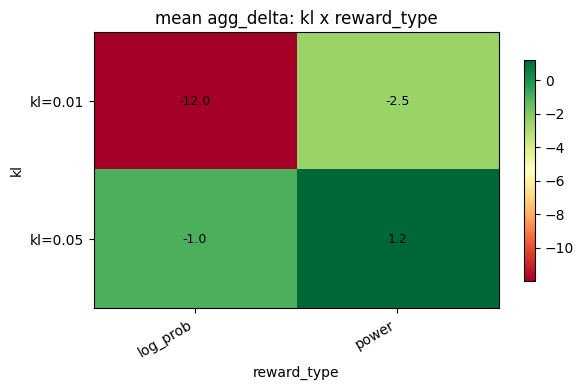

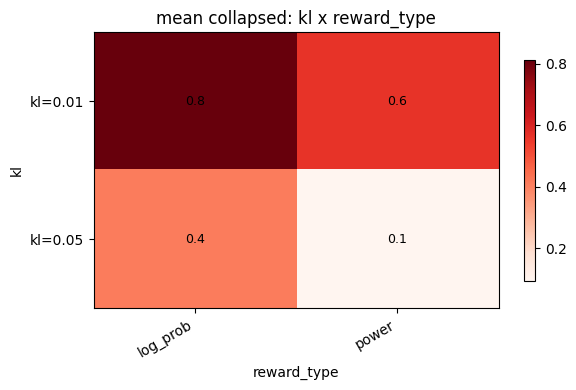

reward_type,log_prob,power
kl_lbl,,
kl=0.01,0.812500,0.56250
kl=0.05,0.411765,0.09375


In [16]:
# 7b. heatmap helper (matplotlib only)
def heatmap(row_knob, col_knob, metric="agg_delta", agg="mean", df=None, annot=True, cmap="RdYlGn"):
    df = runs_df if df is None else df
    rcol = KNOB_COLS.get(row_knob, row_knob); ccol = KNOB_COLS.get(col_knob, col_knob)
    piv = df.pivot_table(index=rcol, columns=ccol, values=metric, aggfunc=agg)
    fig, ax = plt.subplots(figsize=(1.6*len(piv.columns)+3, 1.0*len(piv.index)+2))
    im = ax.imshow(piv.values, cmap=cmap, aspect="auto")
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels(piv.columns, rotation=30, ha="right")
    ax.set_yticks(range(len(piv.index)));   ax.set_yticklabels(piv.index)
    ax.set_xlabel(col_knob); ax.set_ylabel(row_knob)
    ax.set_title(f"{agg} {metric}: {row_knob} x {col_knob}")
    if annot:
        for i in range(piv.shape[0]):
            for j in range(piv.shape[1]):
                v = piv.values[i, j]
                if pd.notna(v):
                    ax.text(j, i, f"{v:.1f}", ha="center", va="center", fontsize=9)
    fig.colorbar(im, ax=ax, shrink=0.8); plt.tight_layout(); plt.show()
    return piv

heatmap("kl", "reward_type", "agg_delta", "mean")
heatmap("kl", "reward_type", "collapsed", "mean", cmap="Reds")   # collapse rate


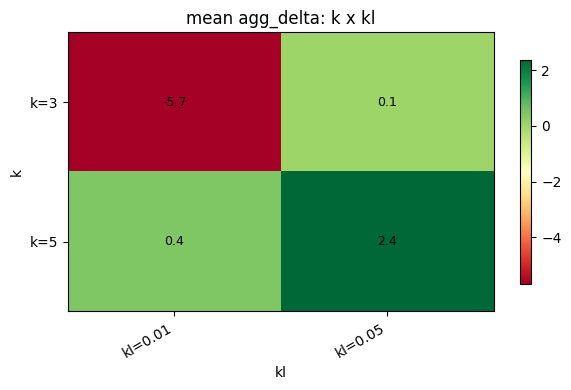

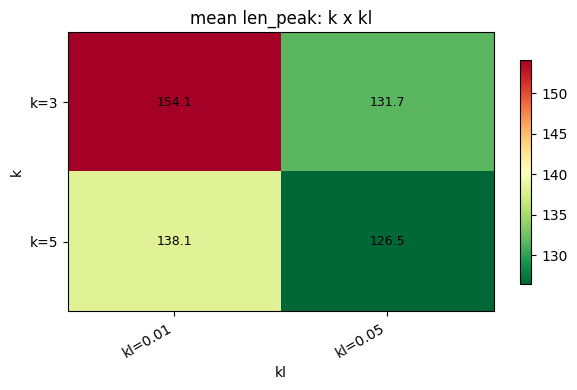

In [17]:
# 7c. k x kl (power only): learning and collapse
pw = runs_df[runs_df["reward_type"] == "power"]
if pw["power_k"].nunique() > 1 and pw["kl"].nunique() > 1:
    heatmap("k", "kl", "agg_delta", "mean", df=pw)
    heatmap("k", "kl", "len_peak",  "mean", df=pw, cmap="RdYlGn_r")
else:
    print("need >=2 distinct k and kl among power runs for this heatmap")


## 8. Consistency across model families

Do knob effects agree across families? For each knob we compute its per-family mean `agg_delta` and
check (a) that the **best knob value** is the same across families and (b) the **correlation** of the
per-value effect vector between family pairs. Degrades gracefully when only one family is present.

In [18]:
fams = [f for f in runs_df["fam_size"].unique() if runs_df[runs_df.fam_size==f].shape[0] >= 2]
print("families with >=2 runs:", fams)

if len(fams) < 2:
    print("\nOnly one model family in the current selection ->",
          "cross-family consistency is N/A. Re-run with NAME_REGEX widened to include other families",
          "(e.g. Qwen3 / Gemma) once those sweeps exist.")
else:
    for knob in ["reward_type", "k", "kl", "fp"]:
        col = KNOB_COLS.get(knob, knob)
        piv = runs_df.pivot_table(index=col, columns="fam_size", values="agg_delta", aggfunc="mean")
        piv = piv[[f for f in fams if f in piv.columns]]
        print(f"\n== {knob}: mean agg_delta per family ==")
        display(piv.round(2))
        best = piv.idxmax()
        print("best value per family:", best.to_dict(),
              "| CONSISTENT" if best.nunique() == 1 else "| DIFFERS across families")
        if piv.shape[1] >= 2 and piv.dropna().shape[0] >= 2:
            print("pairwise correlation of per-value effect vectors:")
            display(piv.dropna().corr().round(2))


families with >=2 runs: ['Qwen2.5-3B']

Only one model family in the current selection -> cross-family consistency is N/A. Re-run with NAME_REGEX widened to include other families (e.g. Qwen3 / Gemma) once those sweeps exist.


## 9. Per-benchmark breakdown

Which benchmarks drive the aggregate, and where does a knob help vs hurt.

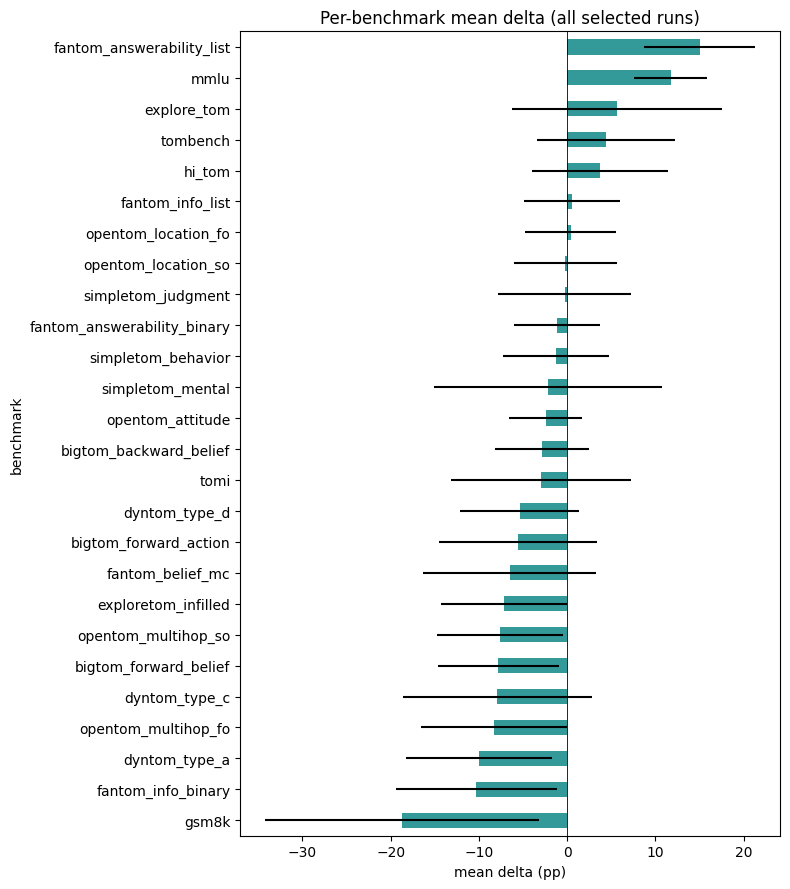

,mean,std,count
benchmark,,,
fantom_answerability_list,15.01,6.33,96
mmlu,11.73,4.13,96
explore_tom,5.63,11.89,96
tombench,4.43,7.81,96
hi_tom,3.73,7.70,96
fantom_info_list,0.53,5.45,96
opentom_location_fo,0.40,5.16,96
opentom_location_so,-0.19,5.81,96
simpletom_judgment,-0.25,7.53,96


In [19]:
# 9a. mean delta per benchmark (which benchmarks move most)
bd = (long_df.groupby("benchmark")["delta"].agg(["mean","std","count"])
      .sort_values("mean", ascending=False).round(2))
ax = bd["mean"].plot.barh(figsize=(8, 9), xerr=bd["std"], color="teal", alpha=0.8)
ax.axvline(0, color="k", lw=0.6); ax.invert_yaxis()
ax.set_xlabel("mean delta (pp)"); ax.set_title("Per-benchmark mean delta (all selected runs)")
plt.tight_layout(); plt.show()
display(bd)


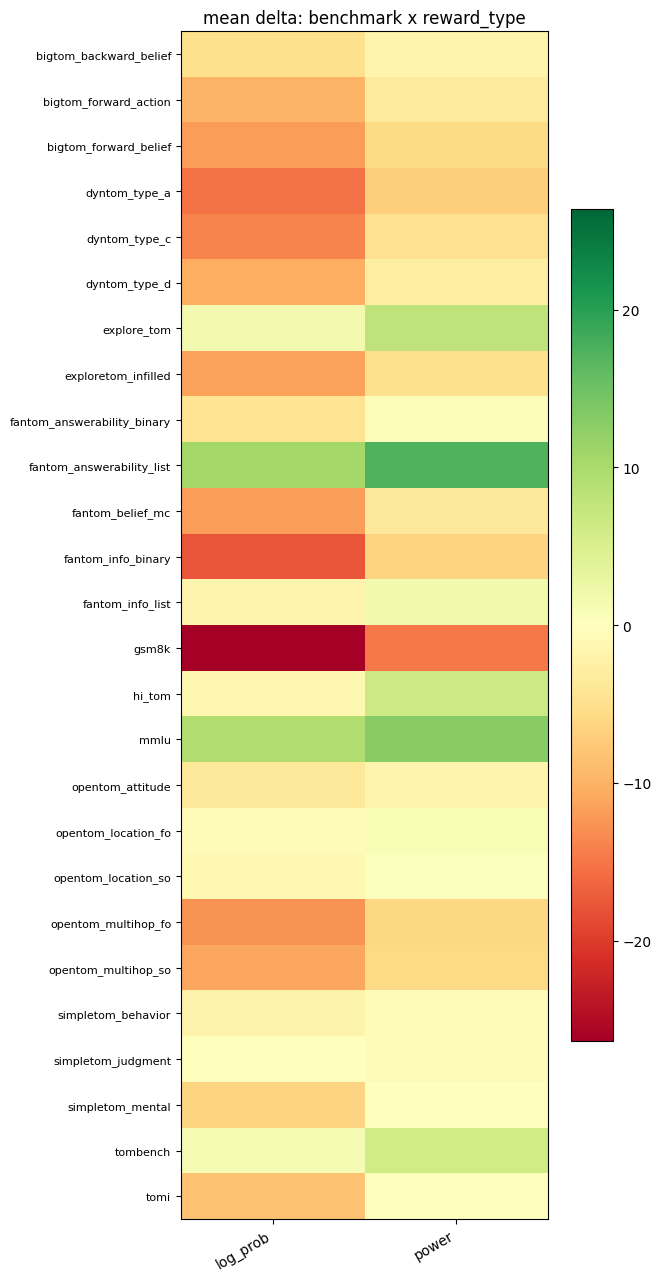

reward_type,log_prob,power
benchmark,,
bigtom_backward_belief,-4.98,-1.70
bigtom_forward_action,-9.84,-3.33
bigtom_forward_belief,-11.77,-5.70
dyntom_type_a,-15.38,-7.20
dyntom_type_c,-13.87,-4.77
dyntom_type_d,-10.35,-2.78
explore_tom,1.44,7.83
exploretom_infilled,-11.39,-4.97
fantom_answerability_binary,-4.37,0.53


In [20]:
# 9b. benchmark x knob heatmap of mean delta (default: reward_type; change knob as needed)
def bench_knob_heatmap(knob="reward_type", metric="delta"):
    col = KNOB_COLS.get(knob, knob)
    piv = long_df.pivot_table(index="benchmark", columns=col, values=metric, aggfunc="mean")
    fig, ax = plt.subplots(figsize=(1.8*piv.shape[1]+3, 0.42*piv.shape[0]+2))
    im = ax.imshow(piv.values, cmap="RdYlGn", aspect="auto",
                   vmin=-abs(np.nanmax(np.abs(piv.values))), vmax=abs(np.nanmax(np.abs(piv.values))))
    ax.set_xticks(range(piv.shape[1])); ax.set_xticklabels(piv.columns, rotation=30, ha="right")
    ax.set_yticks(range(piv.shape[0])); ax.set_yticklabels(piv.index, fontsize=8)
    ax.set_title(f"mean {metric}: benchmark x {knob}")
    fig.colorbar(im, ax=ax, shrink=0.7); plt.tight_layout(); plt.show()
    return piv.round(2)

bench_knob_heatmap("reward_type")


## 10. Select specific runs / tracker rows

Helpers to restrict the whole analysis to an explicit list of run names or tracker `Exp #` ids.
Assign the result to `runs_df` (and rebuild `long_df`) then re-run sections 4-9.

In [21]:
def select_by_names(names):
    return runs_df[runs_df["run_name"].isin(names)].copy()

def select_by_tracker(exp_ids):
    """exp_ids like ['PS075','PS089']; joins tracker Run name -> wandb run_name (prefix match)."""
    want = tracker[tracker["Exp #"].isin(exp_ids)]["Run name"].tolist()
    mask = runs_df["run_name"].apply(lambda n: any(n.startswith(w) or w in n for w in want))
    return runs_df[mask].copy()

# examples (uncomment to use):
# sel = select_by_tracker(["PS075","PS089","PS095"]); display(sel[["run_name","agg_delta","health"]])
# sel = select_by_names([...]) ; 
# runs_df = sel; long_df = to_long(runs_df)   # then re-run analysis cells above
print("Selection helpers ready: select_by_names(...), select_by_tracker([...]).")


Selection helpers ready: select_by_names(...), select_by_tracker([...]).


---
### Notes & caveats
- **smoke_mix** (the Phase -1 probe) is tiny -> aggregate deltas are **noisy**; treat *health/stability*
  and *effect-size ranking* as the primary signal, not exact pp values.
- WandB `state` may read `crashed` even for runs that finished cleanly (verl teardown) - metrics are still
  valid; we read finals from history/summary, not from `state`.
- Cross-family consistency (section 8) activates automatically once non-Qwen2.5 sweeps are added; just widen
  `NAME_REGEX` and set `FORCE_REFRESH=True`.
